# Data Cleaning for NOx emissions

### Import Packages

In [54]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
pio.renderers.default = "notebook"
import os
os.getcwd()

'/Users/maxlaurent/Documents/GitHub/Data_Science_Project'

### Load Data 

In [3]:
df = pd.read_csv("Emissions.csv",sep="\t",low_memory=False)

df.head(10)

,countryCode,country,pollutantName,sectorCode,year,value,unit,notation,parentSectorCode,sectorName
0,AT,Austria,As,1B1b,2017,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
1,AT,Austria,As,1B1b,2018,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
2,AT,Austria,As,1B1b,2019,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
3,AT,Austria,As,1B1b,2020,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
4,AT,Austria,As,1B1b,2021,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
5,AT,Austria,As,1B1b,2022,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
6,AT,Austria,As,1B1b,2023,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
7,AT,Austria,As,1B1b,2024,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
8,AT,Austria,As,1B1c,1990,NaN,t,NR,NATIONAL TOTAL,Other fugitive emissions from solid fuels
9,AT,Austria,As,1B1c,1991,NaN,t,NR,NATIONAL TOTAL,Other fugitive emissions from solid fuels


### Using only useful colums

In [91]:
df.shape

(4511772, 10)

In [92]:
df.columns.tolist()

['countryCode',
 'country',
 'pollutantName',
 'sectorCode',
 'year',
 'value',
 'unit',
 'notation',
 'parentSectorCode',
 'sectorName']

In [18]:
useful_cols = ["country","pollutantName","year","value","unit","sectorName"]

df_bis = pd.read_csv("Emissions.csv",sep="\t",usecols=useful_cols,low_memory=False)

df_bis.head(10)

,country,pollutantName,year,value,unit,sectorName
0,Austria,As,2017,NaN,t,Fugitive emission from solid fuels: Solid fuel...
1,Austria,As,2018,NaN,t,Fugitive emission from solid fuels: Solid fuel...
2,Austria,As,2019,NaN,t,Fugitive emission from solid fuels: Solid fuel...
3,Austria,As,2020,NaN,t,Fugitive emission from solid fuels: Solid fuel...
4,Austria,As,2021,NaN,t,Fugitive emission from solid fuels: Solid fuel...
5,Austria,As,2022,NaN,t,Fugitive emission from solid fuels: Solid fuel...
6,Austria,As,2023,NaN,t,Fugitive emission from solid fuels: Solid fuel...
7,Austria,As,2024,NaN,t,Fugitive emission from solid fuels: Solid fuel...
8,Austria,As,1990,NaN,t,Other fugitive emissions from solid fuels
9,Austria,As,1991,NaN,t,Other fugitive emissions from solid fuels


### Looking only at NOx emissions

In [19]:
df_bis["pollutantName"].dropna().unique()

<StringArray>
[                        'As',                         'BC',
            'Benzo(a) Pyrene',      'Benzo(b) Fluoranthene',
      'benzo(k) Fluoranthene',                         'Cd',
                         'CO',   'Indeno (1,2,3-cd) Pyrene',
                        'NOx',                      'PM2.5',
                         'Zn',                         'Cr',
                         'Pb',                         'Se',
                        'NH3',                       'PCBs',
                         'Cu',                         'Ni',
                        'SOx', 'PCDD/PCDF (dioxins/furans)',
                      'NMVOC',                        'HCB',
                 'Total PAHs',                       'PM10',
                        'TSP',                         'Hg',
                    'Biomass',              'Gaseous Fuels',
               'Liquid Fuels',                'Other Fuels',
                'Solid Fuels']
Length: 31, dtype: str

In [20]:
df_NOx = df_bis[df_bis["pollutantName"].str.upper().eq("NOX")].copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
25945,Austria,NOx,2023,NaN,kt,Biological treatment of waste - Solid waste di...
25946,Austria,NOx,2024,NaN,kt,Biological treatment of waste - Solid waste di...
25947,Austria,NOx,1987,NaN,kt,Biological treatment of waste - Composting
25948,Austria,NOx,1988,NaN,kt,Biological treatment of waste - Composting
25949,Austria,NOx,1989,NaN,kt,Biological treatment of waste - Composting


### Removing rows with no values for NOx emissions

In [21]:
df_NOx = df_NOx.dropna(subset=["value"]).copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
26544,Austria,NOx,1990,0.019140,kt,Municipal waste incineration
26545,Austria,NOx,1991,0.019140,kt,Municipal waste incineration
26887,Austria,NOx,1987,0.017732,kt,Industrial waste incineration
26888,Austria,NOx,1988,0.017732,kt,Industrial waste incineration
26889,Austria,NOx,1989,0.017732,kt,Industrial waste incineration


### Considering values after 2000

In [103]:
df_NOx = df_NOx[
    (df_NOx["year"] >= 2000)
].copy()

df_NOx

,country,pollutantName,year,value,unit,sectorName
26900,Austria,NOx,2000,0.024180,kt,Industrial waste incineration
26901,Austria,NOx,2001,0.024180,kt,Industrial waste incineration
26902,Austria,NOx,2002,0.024180,kt,Industrial waste incineration
26903,Austria,NOx,2003,0.024180,kt,Industrial waste incineration
26904,Austria,NOx,2004,0.024180,kt,Industrial waste incineration
...,...,...,...,...,...,...
4511625,EU27,NOx,2009,88.368465,kt,Agriculture/Forestry/Fishing: National fishing
4511667,EU27,NOx,2020,0.303015,kt,Fugitive emission from solid fuels: Solid fuel...
4511669,EU27,NOx,2023,0.002542,kt,Printing
4511751,EU27,NOx,2013,111.284276,kt,Urine and dung deposited by grazing animals


### Considering total emissions and road transport emissions in countries

In [104]:
df_NOx["sectorName"].unique()

<StringArray>
[                                                      'Industrial waste incineration',
                                                         'Clinical waste incineration',
                                                                           'Cremation',
                                                               'Open burning of waste',
                                                                         'Adjustments',
   'National total for compliance assessment  (please specify all details in the IIR)',
                        'National total for the entire territory (based on fuel sold)',
                                                        'Municipal waste incineration',
                                              'Public electricity and heat production',
                                                                  'Petroleum refining',
 ...
                                                      'Crop residues applied to soils',
 'Other (incl

For NOx emissions within the countries, we will use :   
- 'National total for the entire territory (based on fuel sold)'.
- 'Road transport: Passenger cars'.   

In order to compare total emissions to passenger car emissions within countries.

Meaning of “based on fuel sold” : It means that emissions from fuel combustion are attributed to countries when the relevant fuel was sold in it, using the fuel quantity and pollutant-specific emission factors.

In [105]:
total_sector = "National total for the entire territory (based on fuel sold)"

df_NOx_total = df_NOx[df_NOx["sectorName"].eq(total_sector)].copy()

df_NOx_total.head()

,country,pollutantName,year,value,unit,sectorName
30454,Austria,NOx,2000,211.911,kt,National total for the entire territory (based...
30455,Austria,NOx,2001,222.932,kt,National total for the entire territory (based...
30456,Austria,NOx,2002,231.171,kt,National total for the entire territory (based...
30457,Austria,NOx,2003,242.719,kt,National total for the entire territory (based...
30458,Austria,NOx,2004,243.363,kt,National total for the entire territory (based...


In [106]:
road_transport = "Road transport: Passenger cars"

df_NOx_transport = df_NOx[df_NOx["sectorName"].eq(road_transport)].copy()

df_NOx_transport.head()

,country,pollutantName,year,value,unit,sectorName
158912,Austria,NOx,2000,39.8496,kt,Road transport: Passenger cars
158913,Austria,NOx,2001,42.4431,kt,Road transport: Passenger cars
158914,Austria,NOx,2002,48.9521,kt,Road transport: Passenger cars
158915,Austria,NOx,2003,54.2146,kt,Road transport: Passenger cars
158916,Austria,NOx,2004,56.6985,kt,Road transport: Passenger cars


### Filtering countries

In [107]:
df_NOx_total["country"].unique()

<StringArray>
[      'Austria',       'Belgium',      'Bulgaria',        'Cyprus',
       'Czechia',       'Germany',       'Denmark',       'Estonia',
         'Spain',       'Finland',        'France',        'Greece',
       'Croatia',       'Hungary',       'Ireland',         'Italy',
     'Lithuania',    'Luxembourg',        'Latvia',         'Malta',
   'Netherlands',        'Poland',      'Portugal',       'Romania',
        'Sweden',      'Slovenia',      'Slovakia',   'Switzerland',
       'Iceland', 'Liechtenstein',        'Norway',       'Türkiye',
         'EEA32',          'EU27']
Length: 34, dtype: str

In [119]:
considered_countries=["Norway","Sweden"]

df_NOx_total_clean = (df_NOx_total[df_NOx_total["country"].isin(considered_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_total_clean.head()

,country,pollutantName,year,value,unit,sectorName
0,Norway,NOx,2000,214.203,kt,National total for the entire territory (based...
1,Norway,NOx,2001,212.621,kt,National total for the entire territory (based...
2,Norway,NOx,2002,207.213,kt,National total for the entire territory (based...
3,Norway,NOx,2003,208.983,kt,National total for the entire territory (based...
4,Norway,NOx,2004,207.580,kt,National total for the entire territory (based...


In [120]:
df_NOx_transport_clean = (df_NOx_transport[df_NOx_transport["country"].isin(considered_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_transport_clean.head()

,country,pollutantName,year,value,unit,sectorName
0,Norway,NOx,2000,18.6085,kt,Road transport: Passenger cars
1,Norway,NOx,2001,17.4360,kt,Road transport: Passenger cars
2,Norway,NOx,2002,16.4611,kt,Road transport: Passenger cars
3,Norway,NOx,2003,15.5097,kt,Road transport: Passenger cars
4,Norway,NOx,2004,14.9234,kt,Road transport: Passenger cars


### Univariate analysis

#### Total emissions of NOx in countries (all sectors)

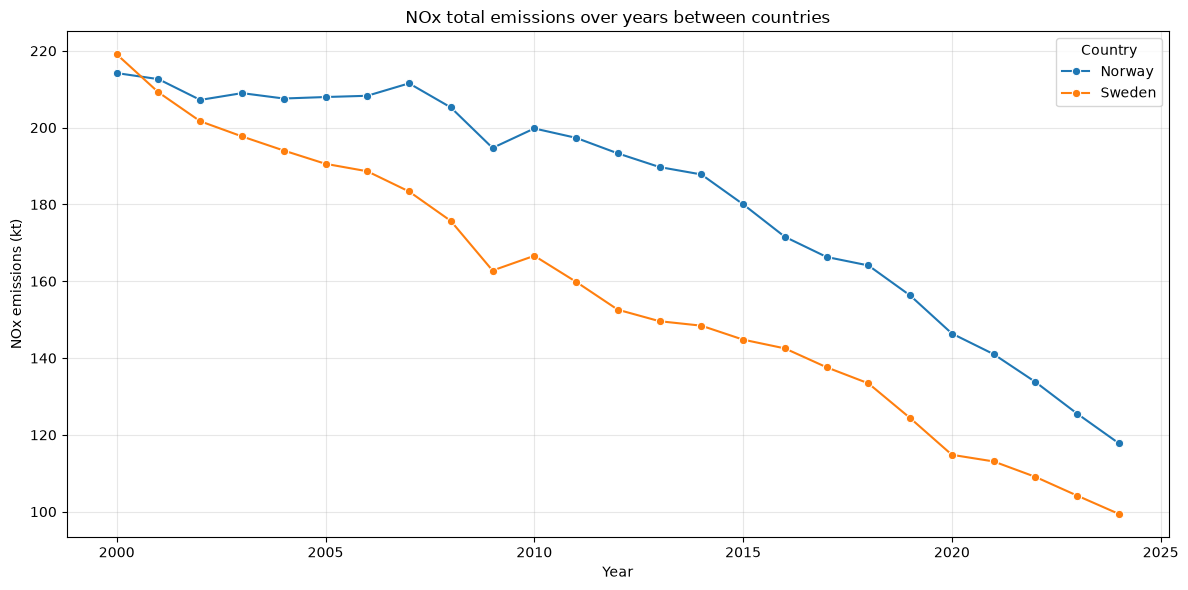

In [110]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_total_clean,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("NOx total emissions over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions (kt)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Road transport related NOx emissions in countries

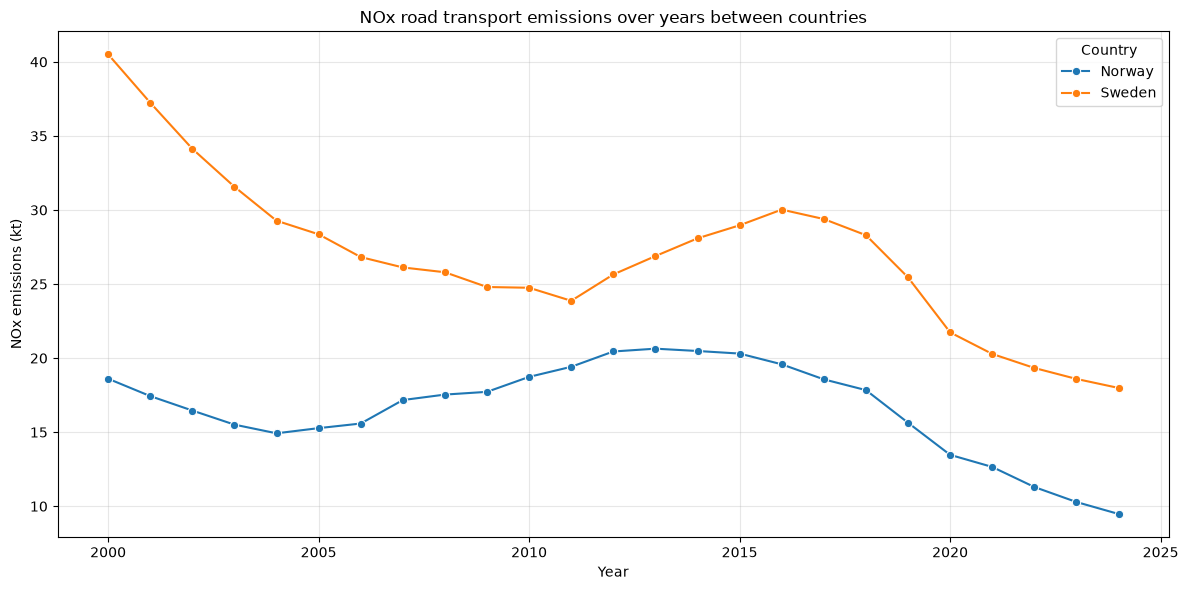

In [111]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_transport_clean,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("NOx road transport emissions over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions (kt)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Share of NOx emissions related to road transport

In [113]:
final_clean_dataset = (
    df_NOx_transport_clean
    .groupby(["country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={
        "value": "Road transport emissions (kt)"
    })
    .merge(
        df_NOx_total_clean[
            ["country", "year", "value"]
        ].rename(columns={
            "value": "Total NOx emissions (kt)"
        }),
        on=["country", "year"],
        how="inner"
    )
    .assign(
        Road_transport_share_pct=lambda x: (
            x["Road transport emissions (kt)"]
            / x["Total NOx emissions (kt)"]
            * 100
        )
    )
)

final_clean_dataset.head(10)

,country,year,Road transport emissions (kt),Total NOx emissions (kt),Road_transport_share_pct
0,Norway,2000,18.6085,214.203,8.687320
1,Norway,2001,17.4360,212.621,8.200507
2,Norway,2002,16.4611,207.213,7.944048
3,Norway,2003,15.5097,208.983,7.421513
4,Norway,2004,14.9234,207.580,7.189228
5,Norway,2005,15.2725,207.968,7.343678
6,Norway,2006,15.5838,208.293,7.481672
7,Norway,2007,17.1686,211.530,8.116390
8,Norway,2008,17.5379,205.259,8.544278
9,Norway,2009,17.7228,194.711,9.102105


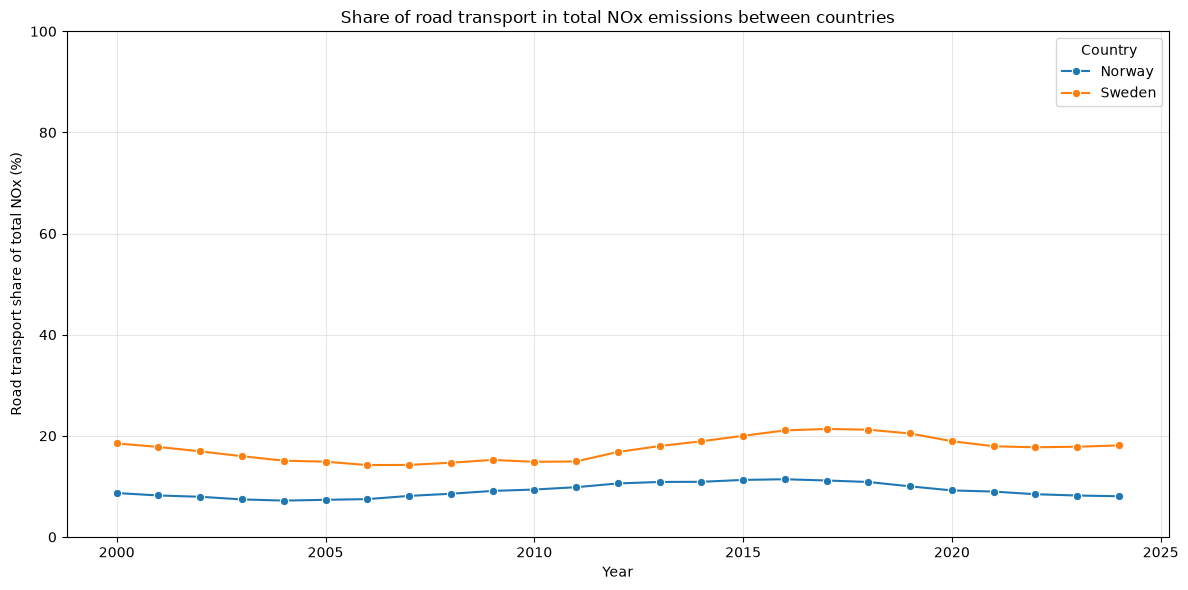

In [115]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=final_clean_dataset,
    x="year",
    y="Road_transport_share_pct",
    hue="country",
    marker="o"
)

plt.title("Share of road transport in total NOx emissions between countries")
plt.xlabel("Year")
plt.ylabel("Road transport share of total NOx (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Taking population into account